In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les images
train_images = np.load("kmnist-train-imgs.npz")["arr_0"]
train_labels = np.load("kmnist-train-labels.npz")["arr_0"]

test_images = np.load("kmnist-test-imgs.npz")["arr_0"]
test_labels = np.load("kmnist-test-labels.npz")["arr_0"]

print("Train Images :", train_images.shape)
print("Train Labels :", train_labels.shape)

print("Test Images :", test_images.shape)
print("Test Labels :", test_labels.shape)



# read alphabet from csv
class_map = pd.read_csv("kmnist_classmap.csv")
print(class_map)

# Afficher une image avec son vrai caractère
for i in range(10):

    label = train_labels[i]

    character = class_map.loc[label, "char"]

    plt.figure(figsize=(2,2))
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"{label} -> {character}")
    plt.axis("off")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'kmnist-train-imgs.npz'

In [2]:
# Ch7al mn classe kayna?
import numpy as np

# Nombre de classes
classes = np.unique(train_labels)

print("Classes :", classes)
print("Nombre de classes :", len(classes))

Classes : [0 1 2 3 4 5 6 7 8 9]
Nombre de classes : 10


In [3]:
# Ch7al mn image f kol classe?
unique, counts = np.unique(train_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Classe {label} : {count} images")

Classe 0 : 6000 images
Classe 1 : 6000 images
Classe 2 : 6000 images
Classe 3 : 6000 images
Classe 4 : 6000 images
Classe 5 : 6000 images
Classe 6 : 6000 images
Classe 7 : 6000 images
Classe 8 : 6000 images
Classe 9 : 6000 images


In [4]:
# Wach dataset équilibré?
if np.all(counts == counts[0]):
    print("✅ Dataset équilibré")
else:
    print("❌ Dataset non équilibré")

✅ Dataset équilibré


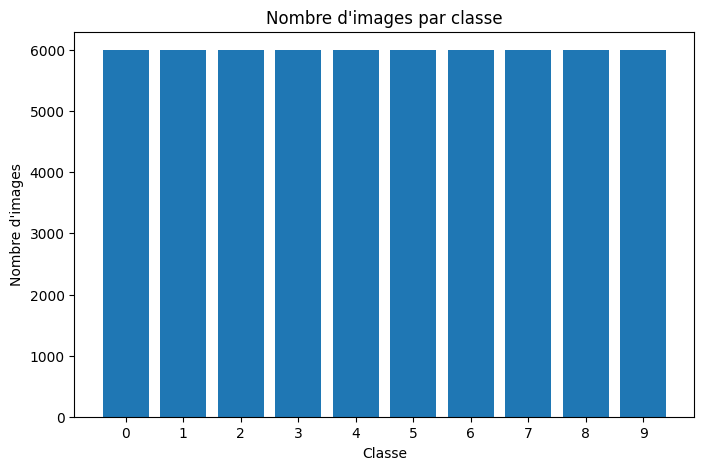

In [5]:
# Had graph ghadi ywarik ch7al mn image kayna f kol classe.
import matplotlib.pyplot as plt
import numpy as np

# Nombre d'images par classe
unique, counts = np.unique(train_labels, return_counts=True)

# Création du graphique
plt.figure(figsize=(8,5))

plt.bar(unique, counts)

plt.title("Nombre d'images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")

plt.xticks(unique)

plt.show()

In [6]:
# ETAPE Preprocessing

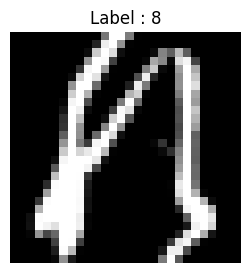

In [7]:
# ETAPE 2.1 Visualiser image originale
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.imshow(train_images[0], cmap="gray")
plt.title(f"Label : {train_labels[0]}")
plt.axis("off")
plt.show()

In [8]:
# ETAPE 2.2 Vérifier les dimensions
print(train_images.shape)
print(train_images[0].shape)

(60000, 28, 28)
(28, 28)


In [9]:
# ETAPE 2.3 Vérifier les valeurs des pixels
print(train_images[0].min())
print(train_images[0].max())

0
255


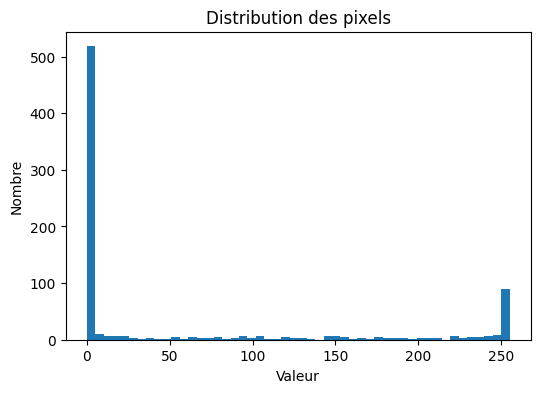

In [10]:
# ETAPE 2.4 Histogramme des pixels
# Hadi katbayan distribution dyal pixels.
plt.figure(figsize=(6,4))

plt.hist(train_images[0].ravel(), bins=50)

plt.title("Distribution des pixels")

plt.xlabel("Valeur")

plt.ylabel("Nombre")

plt.show()

In [11]:
# ETAPE 2.5 Normalization
train_images_norm = train_images.astype("float32") / 255.0
test_images_norm = test_images.astype("float32") / 255.0

print(train_images_norm.min())
print(train_images_norm.max())


0.0
1.0


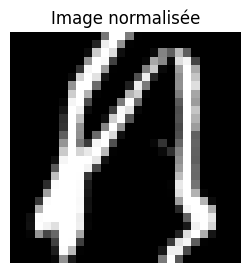

In [12]:
# ETAPE 2.6 Afficher image après Normalization
plt.figure(figsize=(3,3))

plt.imshow(train_images_norm[0], cmap="gray")

plt.title("Image normalisée")

plt.axis("off")

plt.show()

In [13]:
# ETAPE 2.7 Vérifier le type
print(train_images.dtype)

print(train_images_norm.dtype)

# Avant: uint8
# Après: float32

uint8
float32


In [14]:
#📌 ETAPE 3 : Feature Extraction (HOG) 

In [15]:
# ETAPE 3.2 Tester 3la image wa7da
from skimage.feature import hog
image = train_images_norm[0]

features = hog(
    image,
    orientations=9,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    block_norm='L2-Hys'
)

print(features.shape)

print("Nombre de Features :", len(features))

(1296,)
Nombre de Features : 1296


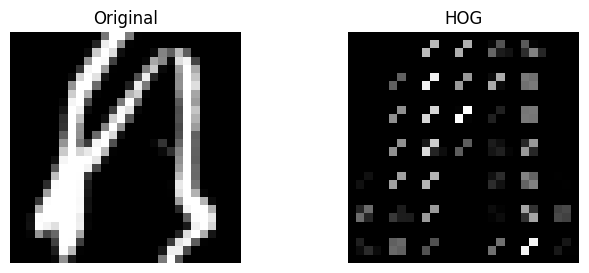

In [16]:
# ETAPE 3.4 Visualiser HOG
from skimage.feature import hog
import matplotlib.pyplot as plt

features, hog_image = hog(
    train_images_norm[0],
    orientations=9,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    block_norm='L2-Hys',
    visualize=True
)

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(train_images_norm[0], cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG")
plt.axis("off")

plt.show()


In [ ]:
# ETAPE 3.5 Transformer tout le Dataset
hog_features = []

for image in train_images_norm:

    feature = hog(
        image,
        orientations=9,
        pixels_per_cell=(4,4), 
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    hog_features.append(feature)

hog_features = np.array(hog_features) # On transforme la liste Python en tableau NumPy

print(hog_features.shape)

(60000, 1296)


In [18]:
print(hog_features.shape)

print(train_labels.shape)


(60000, 1296)
(60000,)


In [19]:
# ETAPE 3.7 Même chose pour Test
hog_test = []

for image in test_images_norm:

    feature = hog(
        image,
        orientations=9,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    hog_test.append(feature)

hog_test = np.array(hog_test)

In [20]:
# ETAPE 3.8 Vérification
print(hog_test.shape)

(10000, 1296)


In [21]:
# 📌 ETAPE 4 : Entraînement des modèles (Machine Learning)

In [22]:
# ETAPE 4.1 Import
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [ ]:
# ETAPE 4.2 Entraîner KNN
knn = KNeighborsClassifier(n_neighbors=3) # Cette ligne crée le modèle KNN.

knn.fit(hog_features, train_labels)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
# Prediction
knn_pred = knn.predict(hog_test)

In [25]:
# Accuracy
knn_acc = accuracy_score(test_labels, knn_pred)

print("Accuracy KNN :", knn_acc)

Accuracy KNN : 0.9521


In [26]:
# ETAPE 4.3 Entraîner SVM
svm = SVC(kernel='linear')

svm.fit(hog_features, train_labels)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
# Prediction
svm_pred = svm.predict(hog_test)

In [28]:
# Accuracy
svm_acc = accuracy_score(test_labels, svm_pred)

print("Accuracy SVM :", svm_acc)

Accuracy SVM : 0.878


In [29]:
# ETAPE 4.4 Entraîner Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(hog_features, train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
# Prediction
rf_pred = rf.predict(hog_test)

In [31]:
# Accuracy
rf_acc = accuracy_score(test_labels, rf_pred)

print("Accuracy RF :", rf_acc)

Accuracy RF : 0.8489


In [32]:
# ETAPE 4.5 Comparaison
print("KNN :", knn_acc)

print("SVM :", svm_acc)

print("Random Forest :", rf_acc)

KNN : 0.9521
SVM : 0.878
Random Forest : 0.8489


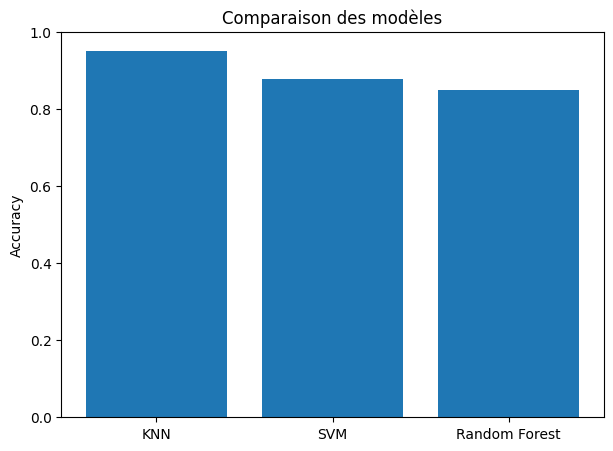

In [33]:
# ETAPE 4.6 Graphique
import matplotlib.pyplot as plt

models = ['KNN','SVM','Random Forest']

scores = [knn_acc, svm_acc, rf_acc]

plt.figure(figsize=(7,5))

plt.bar(models, scores)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Comparaison des modèles")

plt.show()

In [34]:
# 📌 Sauvegarder le meilleur modèle
import joblib
joblib.dump(knn, "best_knn_model.pkl", compress=3)

['best_knn_model.pkl']

In [35]:
#📌 ETAPE 5 : Évaluation du modèle

In [36]:
# ETAPE 5.1 Classification Report
from sklearn.metrics import classification_report
print(classification_report(test_labels, knn_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1000
           1       0.96      0.95      0.95      1000
           2       0.92      0.93      0.93      1000
           3       0.96      0.98      0.97      1000
           4       0.95      0.91      0.93      1000
           5       0.98      0.92      0.95      1000
           6       0.91      0.97      0.94      1000
           7       0.98      0.98      0.98      1000
           8       0.93      0.98      0.95      1000
           9       0.99      0.94      0.96      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [37]:
# 📌 ETAPE 5.2 Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, knn_pred)

print(cm)

[[959   3   2   3  12   2   2   8   8   1]
 [  1 946   8   0   4   0  31   2   5   3]
 [  5   4 933  12   8   6  15   1  14   2]
 [  2   0  12 979   0   2   3   1   1   0]
 [ 25   9   1  12 909   1  16   1  24   2]
 [  3   7  31   9   3 924  14   0   7   2]
 [  2   7   8   2   2   2 974   2   1   0]
 [  2   1   4   0   6   1   1 981   4   0]
 [  2  11   1   4   1   0   3   0 977   1]
 [ 13   0  13   1   9   2   8   8   7 939]]


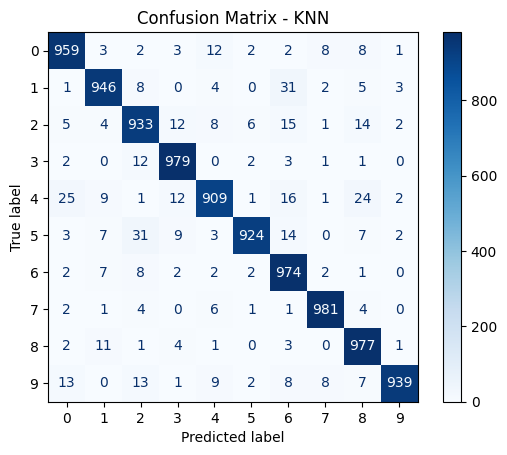

In [38]:
# ETAPE 5.3 Affichage graphique
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - KNN")

plt.show()

In [39]:
# ETAPE 5.4 Accuracy finale
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_labels, knn_pred)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 95.21%


In [40]:
# ETAPE 5.5 Nombre d'erreurs
import numpy as np

errors = np.sum(knn_pred != test_labels)

print("Nombre d'erreurs :", errors)

Nombre d'erreurs : 479


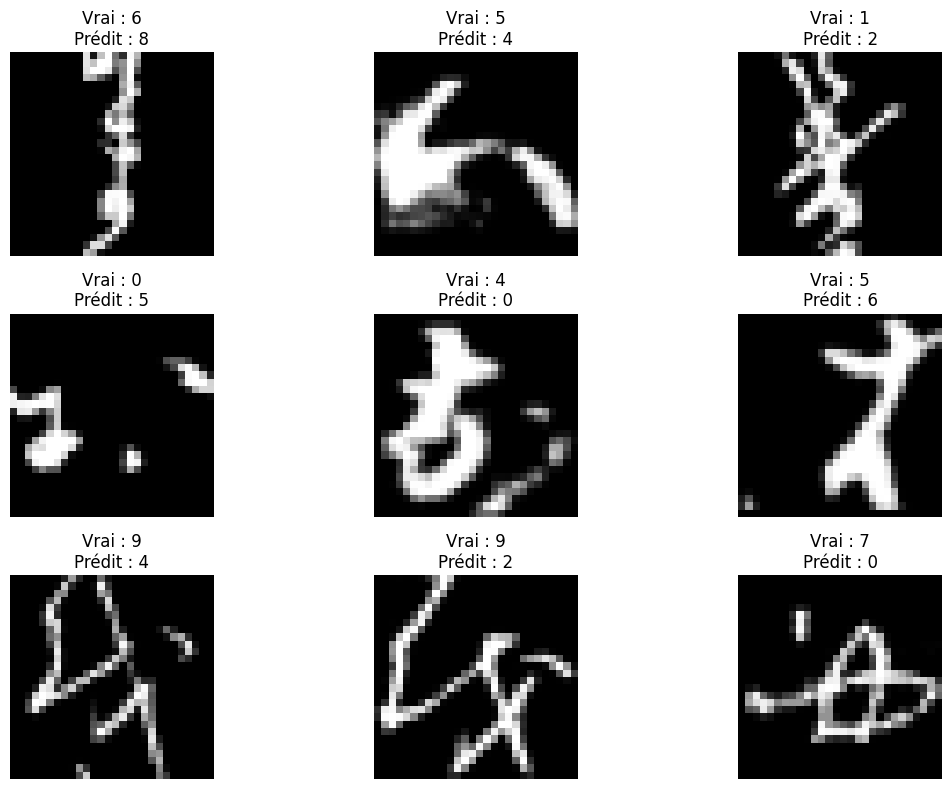

In [41]:
# ETAPE 5.6 Afficher quelques erreurs
import matplotlib.pyplot as plt
import numpy as np

errors = np.where(knn_pred != test_labels)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(test_images[idx], cmap="gray")

    plt.title(f"Vrai : {test_labels[idx]}\nPrédit : {knn_pred[idx]}")

    plt.axis("off")

plt.tight_layout()

plt.show()